In [1]:
# Import required libraries
import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Add acorn to path
SCRIPT_DIR = Path.cwd()
WORKSPACE_ROOT = SCRIPT_DIR.parent
sys.path.insert(0, str(WORKSPACE_ROOT / 'acorn'))

# Import directly to avoid circular dependency issue
from acorn.stages.graph_construction.models import metric_learning
MetricLearning = metric_learning.MetricLearning

print("Imports successful!")

/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/lightning_fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Imports successful!


In [2]:
# Can't use normal import with parentheses in directory name — just define load_model inline
def load_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    hparams = checkpoint['hyper_parameters']
    print(f"Model: {hparams['node_features']} → {hparams['nb_layer']}x{hparams['emb_hidden']} → {hparams['emb_dim']}D")
    model = MetricLearning(hparams)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    return model, hparams

checkpoint_name = "low_pt_latentmodel_100_mixed_f1=0.2752.ckpt"
checkpoint_path = SCRIPT_DIR / 'saved_models' / checkpoint_name
model, hparams = load_model(checkpoint_path)

Model: ['hit_r', 'hit_phi', 'hit_z'] → 5x64 → 7D


In [3]:
example_graph = "event000000000-graph.pyg"

#graph = torch.load(SCRIPT_DIR / 'data' / 'feature_store' /'trainset'/ example_graph)


graph = torch.load(SCRIPT_DIR / "data"/'feature_store' /'trainset'/ example_graph)

def map_to_latent_space(model, graph, node_features):
    # Extract features from graph
    feature_list = []
    for feat_name in node_features:
        feature_list.append(getattr(graph, feat_name))

    
    x = torch.stack(feature_list, dim=1).float()
    # Get embeddings
    with torch.no_grad():
        embeddings = model(x)
    return embeddings



# Map hits to latent space
embeddings = map_to_latent_space(model, graph, hparams['node_features'])

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}D")

Embeddings shape: torch.Size([3381, 7])
Embedding dimension: 7D


In [4]:
graph

Data(hit_id=[3381], hit_x=[3381], hit_r=[3381], hit_z=[3381], hit_segment_id=[3381], hit_t=[3381], hit_y=[3381], hit_phi=[3381], hit_region=[3381], hit_particle_id=[3381], hit_eta=[3381], track_edges=[2, 2932], track_particle_type=[2932], track_particle_nhits=[2932], track_particle_eta=[2932], track_particle_radius=[2932], track_particle_id=[2932], track_particle_pt=[2932], config=[1], event_id='000000000')

In [5]:
k = 50  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]
# === PCA 2D ===
from sklearn.decomposition import PCA
import matplotlib.cm as cm

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_k)

print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

colors = cm.rainbow(np.linspace(0, 1, max(len(selected_pids), 1)))
fig, ax = plt.subplots(figsize=(14, 10))
for i, pid in enumerate(selected_pids):
    mask = pids_k == pid
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[colors[i]], label=f'Particle {pid}', s=50)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'Latent Space — PCA 2D ({emb_k.shape[1]}D → 2D), {k} trajectories')
ax.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'unique_pids' is not defined

In [ ]:
# === Helper: prepare data for all visualizations ===
emb_np = embeddings.cpu().detach().numpy()
particle_ids = graph.hit_particle_id.cpu().numpy().astype(np.int64)

# Get unique non-noise particles and assign colors
unique_pids = np.unique(particle_ids)
unique_pids = unique_pids[unique_pids > 0]
n_particles = len(unique_pids)

# Create color map: particle_id -> color
import matplotlib.cm as cm
color_map = {pid: cm.rainbow(i / max(n_particles - 1, 1)) for i, pid in enumerate(unique_pids)}
hit_colors = [color_map.get(pid, (0.5, 0.5, 0.5, 0.3)) for pid in particle_ids]

print(f"Event has {len(particle_ids)} hits, {n_particles} particles")
print(f"Embedding shape: {emb_np.shape}")

Event has 3381 hits, 288 particles
Embedding shape: (3381, 7)


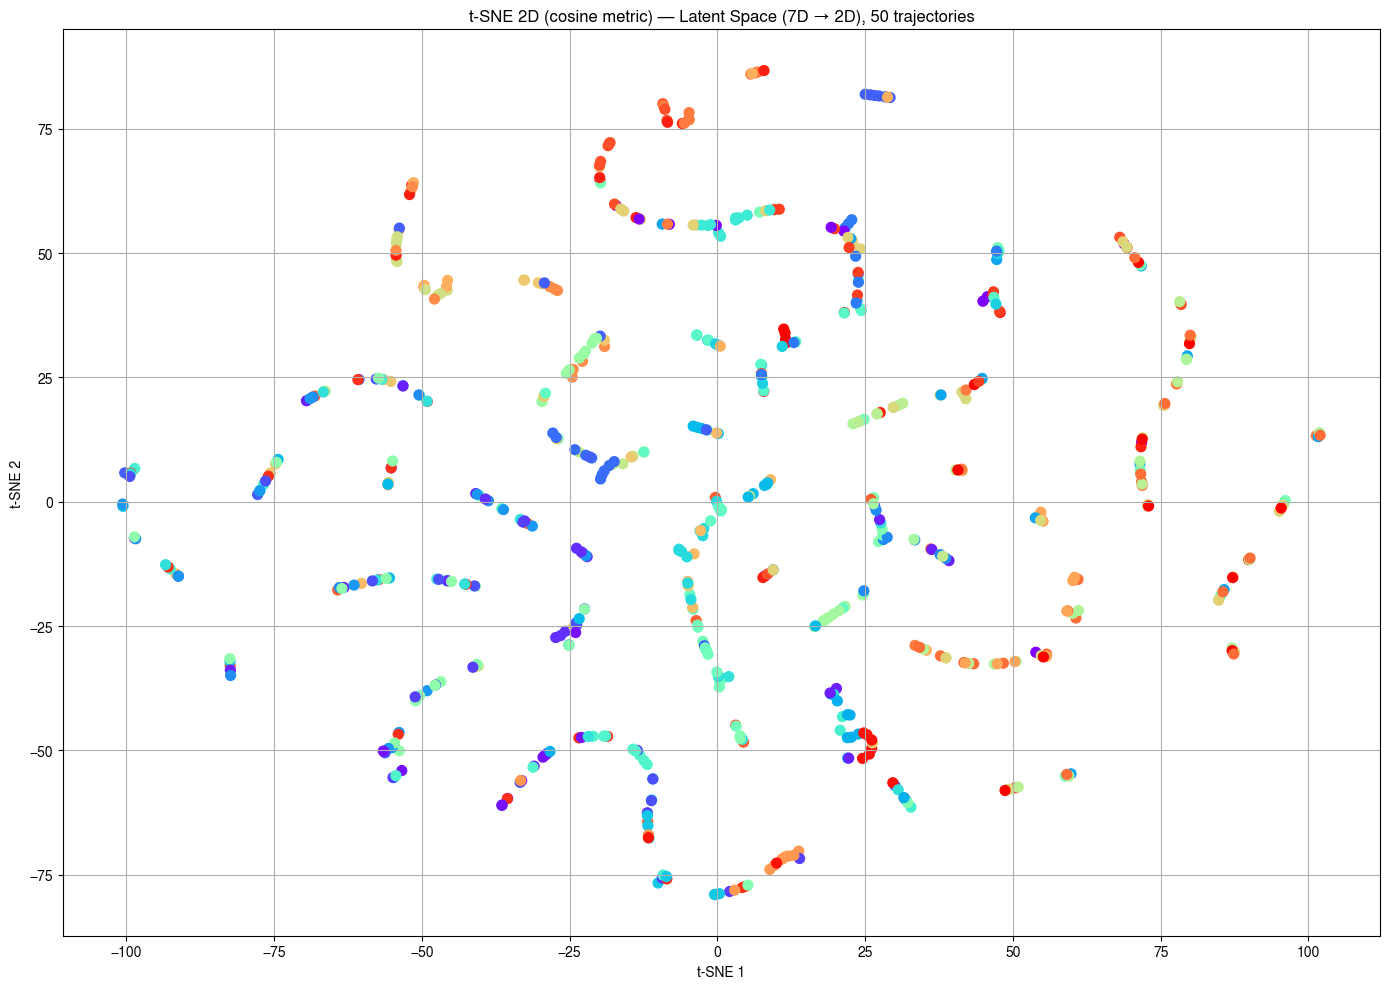

In [ ]:
# === t-SNE 2D (cosine metric — correct for unit-sphere embeddings) ===
from sklearn.manifold import TSNE
import matplotlib.cm as cm

k = 50  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

n_k = len(selected_pids)
color_map_k = {pid: cm.rainbow(i / max(n_k - 1, 1)) for i, pid in enumerate(selected_pids)}
colors_k = [color_map_k[pid] for pid in pids_k]

tsne_2d = TSNE(n_components=2, metric='cosine', perplexity=min(3, len(emb_k)-1), random_state=42)
emb_tsne_2d = tsne_2d.fit_transform(emb_k)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(emb_tsne_2d[:, 0], emb_tsne_2d[:, 1], c=colors_k, s=50)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE 2D (cosine metric) — Latent Space ({emb_k.shape[1]}D → 2D), {k} trajectories')
ax.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# === 3D t-SNE (euclidean metric, interactive plotly) ===
from sklearn.manifold import TSNE
import plotly.graph_objects as go

k = 300  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

tsne_3d = TSNE(n_components=3, metric='euclidean', perplexity=min(3, len(emb_k)-1), random_state=42)
emb_tsne_3d = tsne_3d.fit_transform(emb_k)

fig = go.Figure()
for pid in selected_pids:
    mask = pids_k == pid
    fig.add_trace(go.Scatter3d(
        x=emb_tsne_3d[mask, 0], y=emb_tsne_3d[mask, 1], z=emb_tsne_3d[mask, 2],
        mode='markers',
        marker=dict(size=4),
        name=f'Particle {pid}',
    ))

fig.update_layout(
    title=f't-SNE 3D (Euclidean) — Latent Space, {k} trajectories',
    scene=dict(xaxis_title='t-SNE 1', yaxis_title='t-SNE 2', zaxis_title='t-SNE 3'),
    width=1000, height=700,
)
fig.show()


In [ ]:
# === t-SNE 2D (euclidean metric, interactive plotly) ===
from sklearn.manifold import TSNE
import plotly.graph_objects as go

k = 50  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

tsne_2d_euc = TSNE(n_components=2, metric='euclidean', perplexity=min(3, len(emb_k)-1), random_state=42)
emb_tsne_2d_euc = tsne_2d_euc.fit_transform(emb_k)

fig = go.Figure()
for pid in selected_pids:
    mask = pids_k == pid
    fig.add_trace(go.Scatter(
        x=emb_tsne_2d_euc[mask, 0], y=emb_tsne_2d_euc[mask, 1],
        mode='markers',
        marker=dict(size=8),
        name=f'Particle {pid}',
    ))

fig.update_layout(
    title=f't-SNE 2D (Euclidean) — Latent Space, {k} trajectories',
    xaxis_title='t-SNE 1',
    yaxis_title='t-SNE 2',
    width=1000, height=700,
)
fig.show()


In [ ]:
pip install nbformat --prefix



Usage:   
  /data/alice/bkuipers/miniconda3/envs/acorn_notebook/bin/python -m pip install [options] <requirement specifier> [package-index-options] ...
  /data/alice/bkuipers/miniconda3/envs/acorn_notebook/bin/python -m pip install [options] -r <requirements file> [package-index-options] ...
  /data/alice/bkuipers/miniconda3/envs/acorn_notebook/bin/python -m pip install [options] [-e] <vcs project url> ...
  /data/alice/bkuipers/miniconda3/envs/acorn_notebook/bin/python -m pip install [options] [-e] <local project path> ...
  /data/alice/bkuipers/miniconda3/envs/acorn_notebook/bin/python -m pip install [options] <archive url/path> ...

--prefix option requires 1 argument
Note: you may need to restart the kernel to use updated packages.


/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



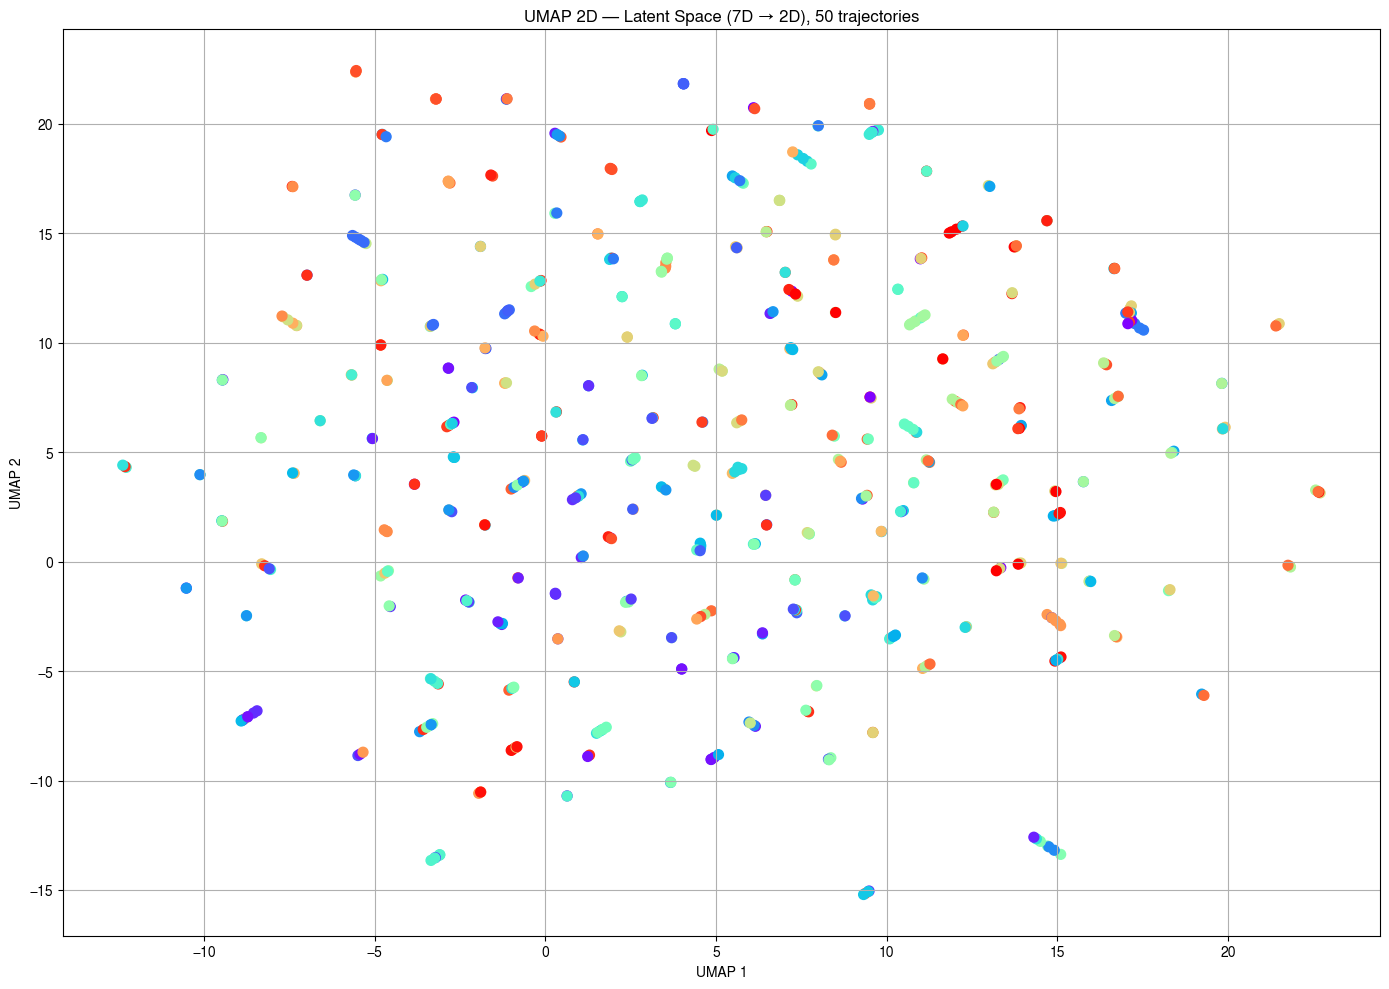

In [ ]:
# === UMAP 2D ===
from umap import UMAP
import matplotlib.cm as cm

k = 50  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

n_k = len(selected_pids)
color_map_k = {pid: cm.rainbow(i / max(n_k - 1, 1)) for i, pid in enumerate(selected_pids)}
colors_k = [color_map_k[pid] for pid in pids_k]

umap_2d = UMAP(n_components=2, metric='euclidean', n_neighbors=2, min_dist=0.3, random_state=42)
emb_umap_2d = umap_2d.fit_transform(emb_k)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(emb_umap_2d[:, 0], emb_umap_2d[:, 1], c=colors_k, s=50)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f'UMAP 2D — Latent Space ({emb_k.shape[1]}D → 2D), {k} trajectories')
ax.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# === 3D PCA (interactive with plotly) ===
import plotly.graph_objects as go
from sklearn.decomposition import PCA

k = 50  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

pca_3d = PCA(n_components=3)
emb_pca_3d = pca_3d.fit_transform(emb_k)

fig = go.Figure()
for pid in selected_pids:
    mask = pids_k == pid
    fig.add_trace(go.Scatter3d(
        x=emb_pca_3d[mask, 0], y=emb_pca_3d[mask, 1], z=emb_pca_3d[mask, 2],
        mode='markers',
        marker=dict(size=4),
        name=f'Particle {pid}',
    ))

fig.update_layout(
    title=f'PCA 3D ({pca_3d.explained_variance_ratio_[:3].sum():.1%} variance), {k} trajectories',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})',
    ),
    width=900, height=700,
)
fig.show()


In [ ]:
# === 3D UMAP (interactive plotly) ===
from umap import UMAP
import plotly.graph_objects as go

k = 50  # number of trajectories to plot
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

umap_3d = UMAP(n_components=3, metric='euclidean', n_neighbors=3, min_dist=0.01, random_state=42)
emb_umap_3d = umap_3d.fit_transform(emb_k)

fig = go.Figure()
for pid in selected_pids:
    mask = pids_k == pid
    fig.add_trace(go.Scatter3d(
        x=emb_umap_3d[mask, 0], y=emb_umap_3d[mask, 1], z=emb_umap_3d[mask, 2],
        mode='markers',
        marker=dict(size=4),
        name=f'Particle {pid}',
    ))

fig.update_layout(
    title=f'UMAP 3D — Latent Space, {k} trajectories',
    scene=dict(xaxis_title='UMAP 1', yaxis_title='UMAP 2', zaxis_title='UMAP 3'),
    width=900, height=700,
)
fig.show()


/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



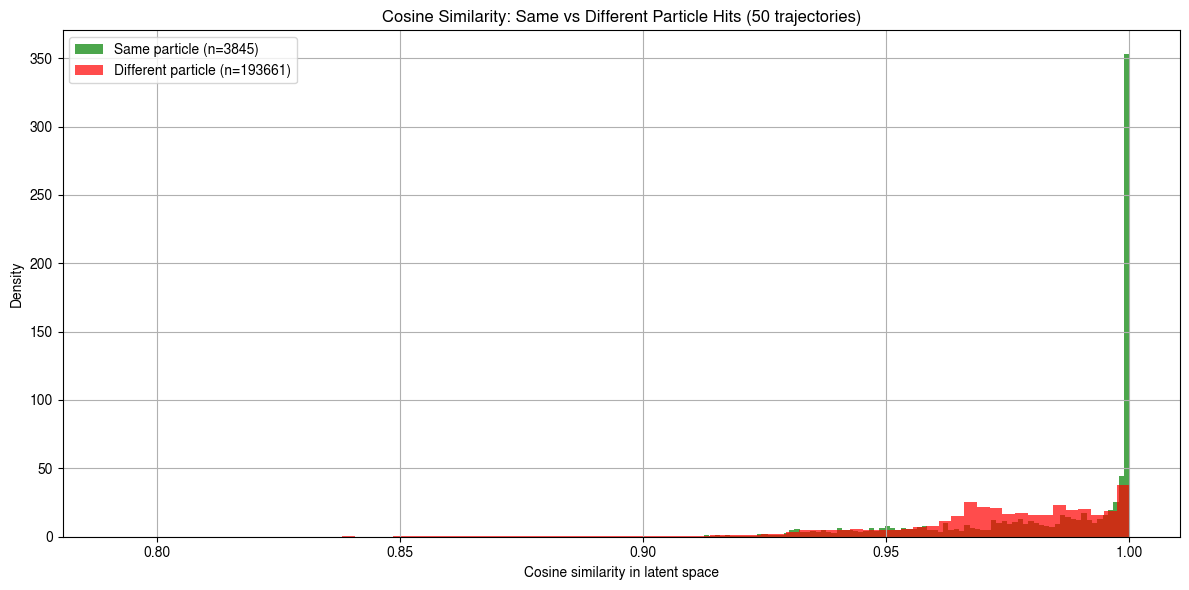

Mean intra-particle similarity: 0.9834
Mean inter-particle similarity: 0.9707


In [ ]:
# === Pairwise COSINE SIMILARITY analysis ===
from scipy.spatial.distance import pdist, squareform

k = 50  # number of trajectories to include
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = particle_ids[fmask]

cos_dist_matrix = squareform(pdist(emb_k, metric='cosine'))
cos_sim_matrix = 1 - cos_dist_matrix

intra_sims = []
inter_sims = []
for i in range(len(pids_k)):
    for j in range(i + 1, len(pids_k)):
        s = cos_sim_matrix[i, j]
        if pids_k[i] == pids_k[j] and pids_k[i] > 0:
            intra_sims.append(s)
        else:
            inter_sims.append(s)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(intra_sims, bins=80, alpha=0.7, label=f'Same particle (n={len(intra_sims)})', density=True, color='green')
ax.hist(inter_sims, bins=80, alpha=0.7, label=f'Different particle (n={len(inter_sims)})', density=True, color='red')
ax.set_xlabel('Cosine similarity in latent space')
ax.set_ylabel('Density')
ax.set_title(f'Cosine Similarity: Same vs Different Particle Hits ({k} trajectories)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean intra-particle similarity: {np.mean(intra_sims):.4f}")
print(f"Mean inter-particle similarity: {np.mean(inter_sims):.4f}")


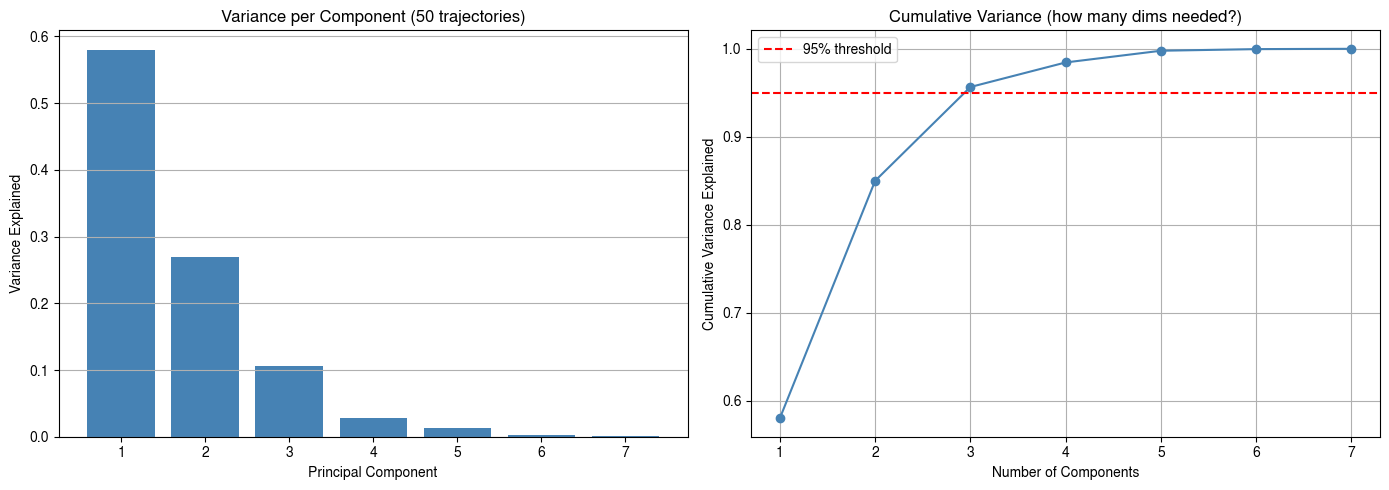

Components needed for 95% variance: 3 out of 7


In [ ]:
# === PCA variance explained per component ===
from sklearn.decomposition import PCA

k = 50  # number of trajectories to include
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]

pca_full = PCA(n_components=emb_k.shape[1])
pca_full.fit(emb_k)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, emb_k.shape[1] + 1), pca_full.explained_variance_ratio_, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title(f'Variance per Component ({k} trajectories)')
ax1.set_xticks(range(1, emb_k.shape[1] + 1))
ax1.grid(True, axis='y')

cumulative = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(range(1, emb_k.shape[1] + 1), cumulative, 'o-', color='steelblue')
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance (how many dims needed?)')
ax2.set_xticks(range(1, emb_k.shape[1] + 1))
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95} out of {emb_k.shape[1]}")


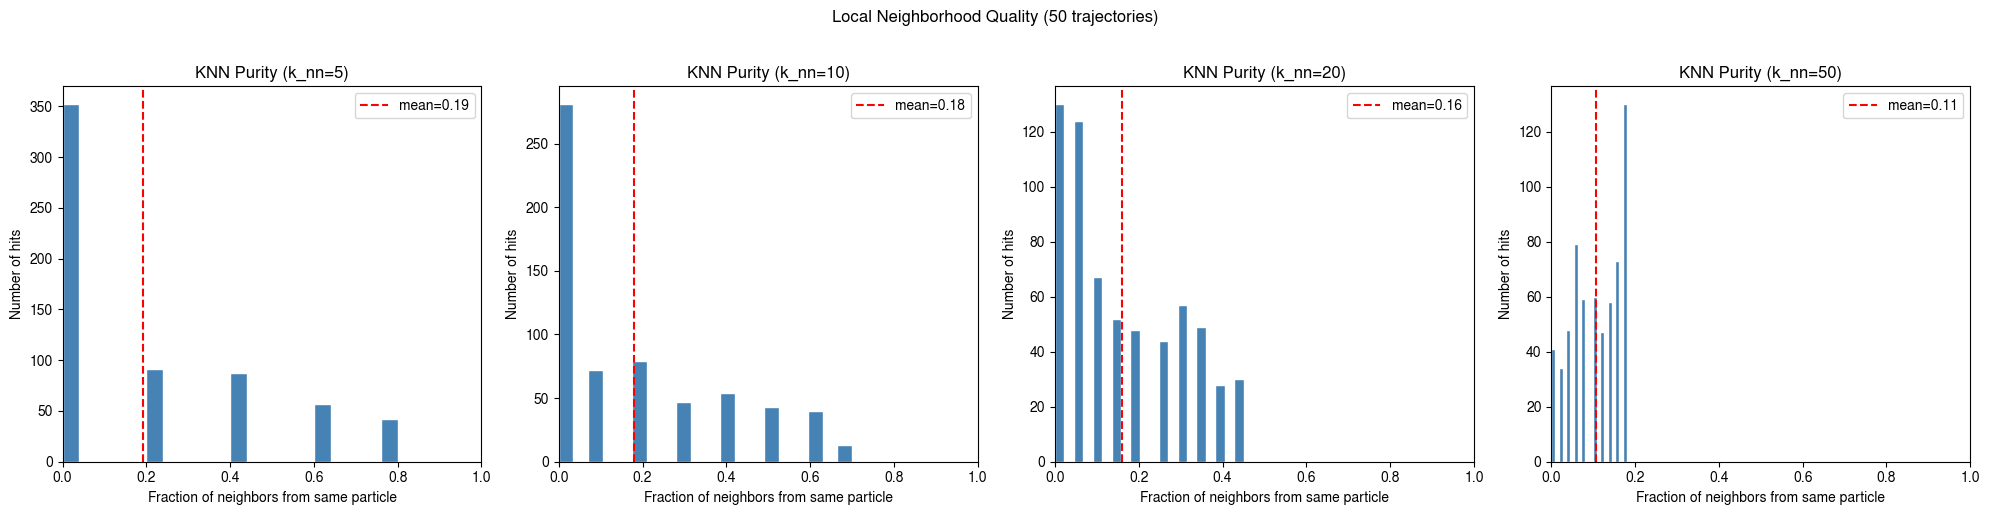

In [ ]:
# === KNN Neighborhood Purity ===
from sklearn.neighbors import NearestNeighbors

k = 50  # number of trajectories to include
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = np.array(particle_ids[fmask], dtype=np.int64)

k_nn_values = [5, 10, 20, 50]
fig, axes = plt.subplots(1, len(k_nn_values), figsize=(5 * len(k_nn_values), 5))

for ax, k_nn in zip(axes, k_nn_values):
    nn = NearestNeighbors(n_neighbors=k_nn + 1, metric='euclidean')
    nn.fit(emb_k)
    _, indices = nn.kneighbors(emb_k)
    indices = indices[:, 1:]

    purities = []
    for i in range(len(pids_k)):
        if pids_k[i] == 0:
            continue
        neighbor_pids = pids_k[indices[i]]
        purity = (neighbor_pids == pids_k[i]).sum() / k_nn
        purities.append(purity)

    ax.hist(purities, bins=20, color='steelblue', edgecolor='white')
    ax.axvline(np.mean(purities), color='red', linestyle='--', label=f'mean={np.mean(purities):.2f}')
    ax.set_xlabel('Fraction of neighbors from same particle')
    ax.set_ylabel('Number of hits')
    ax.set_title(f'KNN Purity (k_nn={k_nn})')
    ax.legend()
    ax.set_xlim(0, 1)

plt.suptitle(f'Local Neighborhood Quality ({k} trajectories)', y=1.02)
plt.tight_layout()
plt.show()


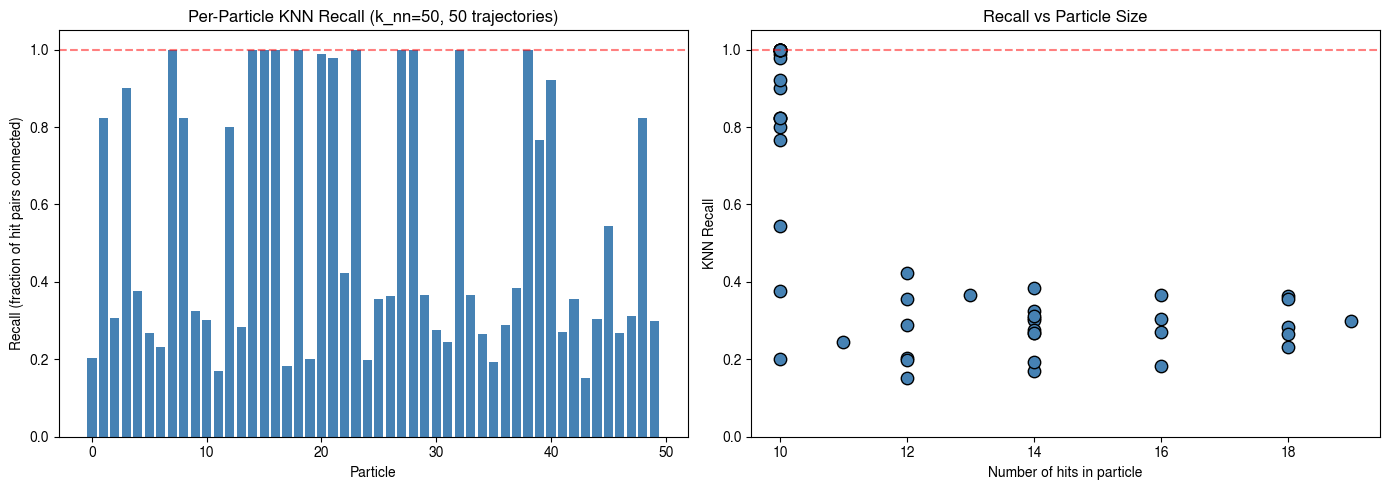

Mean per-particle recall: 0.538
Particles with perfect recall: 10/50


In [ ]:
# === Per-particle KNN recall ===
from sklearn.neighbors import NearestNeighbors

k = 50  # number of trajectories to include
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = np.array(particle_ids[fmask], dtype=np.int64)

k_nn = 50  # match your pipeline's k_max
nn = NearestNeighbors(n_neighbors=k_nn + 1, metric='euclidean')
nn.fit(emb_k)
_, indices = nn.kneighbors(emb_k)
indices = indices[:, 1:]

particle_recalls = []
particle_sizes = []

for pid in selected_pids:
    hit_mask = pids_k == pid
    hit_indices = np.where(hit_mask)[0]
    n_hits = len(hit_indices)
    if n_hits < 2:
        continue

    found_pairs = 0
    total_pairs = n_hits * (n_hits - 1)
    for i in hit_indices:
        neighbors_of_i = set(indices[i])
        for j in hit_indices:
            if i != j and j in neighbors_of_i:
                found_pairs += 1

    recall = found_pairs / total_pairs if total_pairs > 0 else 0
    particle_recalls.append(recall)
    particle_sizes.append(n_hits)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(len(particle_recalls)), particle_recalls, color='steelblue')
ax1.set_xlabel('Particle')
ax1.set_ylabel('Recall (fraction of hit pairs connected)')
ax1.set_title(f'Per-Particle KNN Recall (k_nn={k_nn}, {k} trajectories)')
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 1.05)

ax2.scatter(particle_sizes, particle_recalls, c='steelblue', s=80, edgecolors='black')
ax2.set_xlabel('Number of hits in particle')
ax2.set_ylabel('KNN Recall')
ax2.set_title('Recall vs Particle Size')
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"Mean per-particle recall: {np.mean(particle_recalls):.3f}")
print(f"Particles with perfect recall: {sum(r == 1.0 for r in particle_recalls)}/{len(particle_recalls)}")


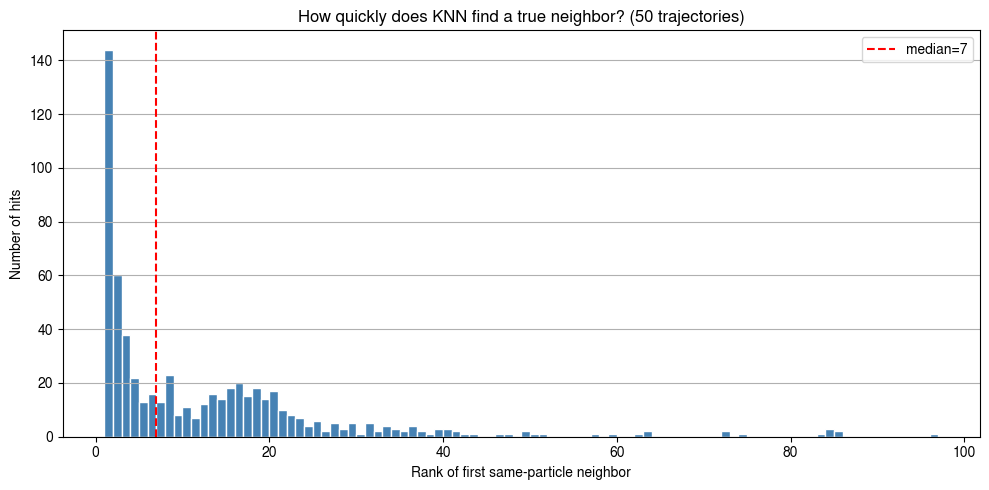

Hits where rank 1 neighbor is same particle: 144/604 (23.8%)


In [ ]:
# === Nearest same-particle neighbor rank ===
from sklearn.neighbors import NearestNeighbors

k = 50  # number of trajectories to include
selected_pids = unique_pids[:k]
selected_set = set(selected_pids.tolist())
fmask = np.array([pid in selected_set for pid in particle_ids])
emb_k = emb_np[fmask]
pids_k = np.array(particle_ids[fmask], dtype=np.int64)

nn = NearestNeighbors(n_neighbors=min(100, len(emb_k) - 1), metric='euclidean')
nn.fit(emb_k)
distances, indices = nn.kneighbors(emb_k)
indices = indices[:, 1:]

first_true_ranks = []
for i in range(len(pids_k)):
    if pids_k[i] == 0:
        continue
    for rank, neighbor_idx in enumerate(indices[i]):
        if pids_k[neighbor_idx] == pids_k[i]:
            first_true_ranks.append(rank + 1)
            break

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(first_true_ranks, bins=range(1, max(first_true_ranks) + 2), color='steelblue', edgecolor='white')
ax.set_xlabel('Rank of first same-particle neighbor')
ax.set_ylabel('Number of hits')
ax.set_title(f'How quickly does KNN find a true neighbor? ({k} trajectories)')
ax.axvline(np.median(first_true_ranks), color='red', linestyle='--', label=f'median={np.median(first_true_ranks):.0f}')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f"Hits where rank 1 neighbor is same particle: {sum(r == 1 for r in first_true_ranks)}/{len(first_true_ranks)} ({100*sum(r==1 for r in first_true_ranks)/len(first_true_ranks):.1f}%)")
